In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import  precision_score, recall_score ,classification_report, ConfusionMatrixDisplay ,roc_curve, roc_auc_score, auc,f1_score,accuracy_score,confusion_matrix,root_mean_squared_error
from sklearn.linear_model import LogisticRegression,LinearRegression,Ridge, Lasso, ElasticNet
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PolynomialFeatures,RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import set_config

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, f_classif

import shap
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel


In [2]:
df_bank=pd.read_csv('bank-additional-full.csv', sep=';')

In [3]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
df_bank['y'] = df_bank['y'].map({'yes': 1, 'no': 0})
df_bank['y'].value_counts()

,count
y,
0,36548
1,4640


The target classes are imbalanced - stratification will be needed when splitting into train and test sets

# EDA

## Categorical columns

In [5]:
object_columns = df_bank.select_dtypes(include=['object']).columns.tolist()
object_df = df_bank.select_dtypes(include=['object'])
report = pd.DataFrame({
    'Unique Values': object_df.nunique(),
    'Data Type': object_df.dtypes,
    'Missing Values': object_df.isnull().sum()
})

print(report)

             Unique Values Data Type  Missing Values
job                     12    object               0
marital                  4    object               0
education                8    object               0
default                  3    object               0
housing                  3    object               0
loan                     3    object               0
contact                  2    object               0
month                   10    object               0
day_of_week              5    object               0
poutcome                 3    object               0


In [6]:
def bi_cat_countplot(df, column, hue_column):
    unique_hue_values = df[hue_column].unique()
    fig, axes = plt.subplots(nrows=1, ncols=2)
    fig.set_size_inches(14,6)

    pltname = f'Normalized value distribution by category: {column}'
    proportions = df.groupby(hue_column)[column].value_counts(normalize=True)
    proportions = (proportions*100).round(2)
    ax = proportions.unstack(hue_column).sort_values(
        by=unique_hue_values[0], ascending=False
        ).plot.bar(ax=axes[0], title=pltname)

    # annotate values on the bar plot
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.1f}%')

    pltname = f'Data count by category: {column}'
    counts = df.groupby(hue_column)[column].value_counts()
    ax = counts.unstack(hue_column).sort_values(
        by=unique_hue_values[0], ascending=False
        ).plot.bar(ax=axes[1], title=pltname)

    for container in ax.containers:
      ax.bar_label(container)


def uni_cat_target_compare(df, column):
    bi_cat_countplot(df, column, hue_column='y' )

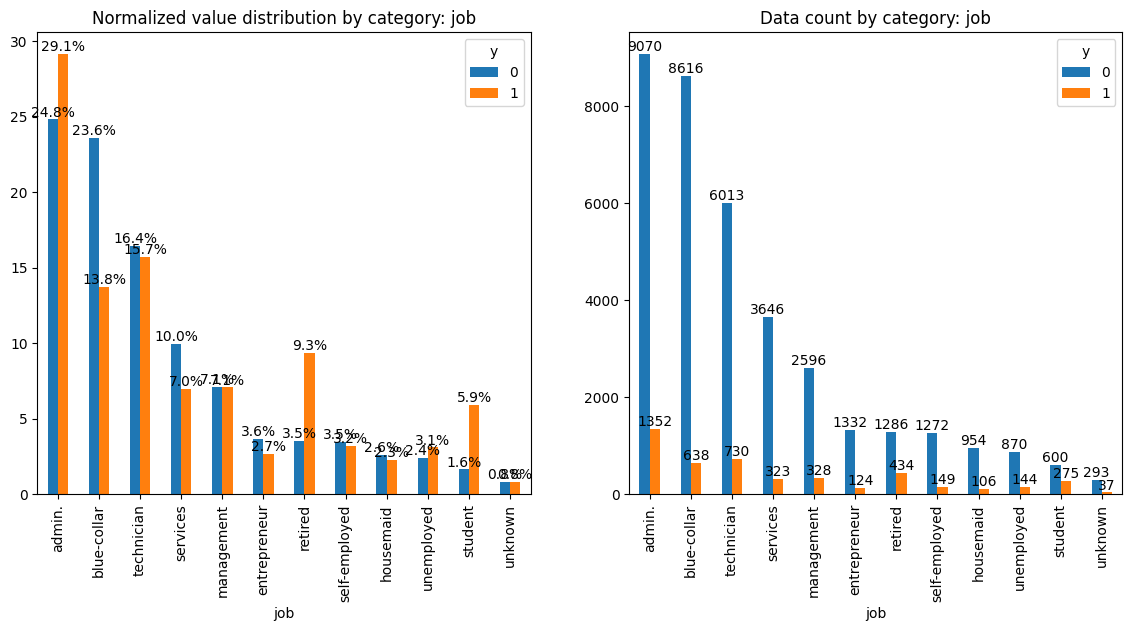

In [7]:
uni_cat_target_compare(df_bank,'job')

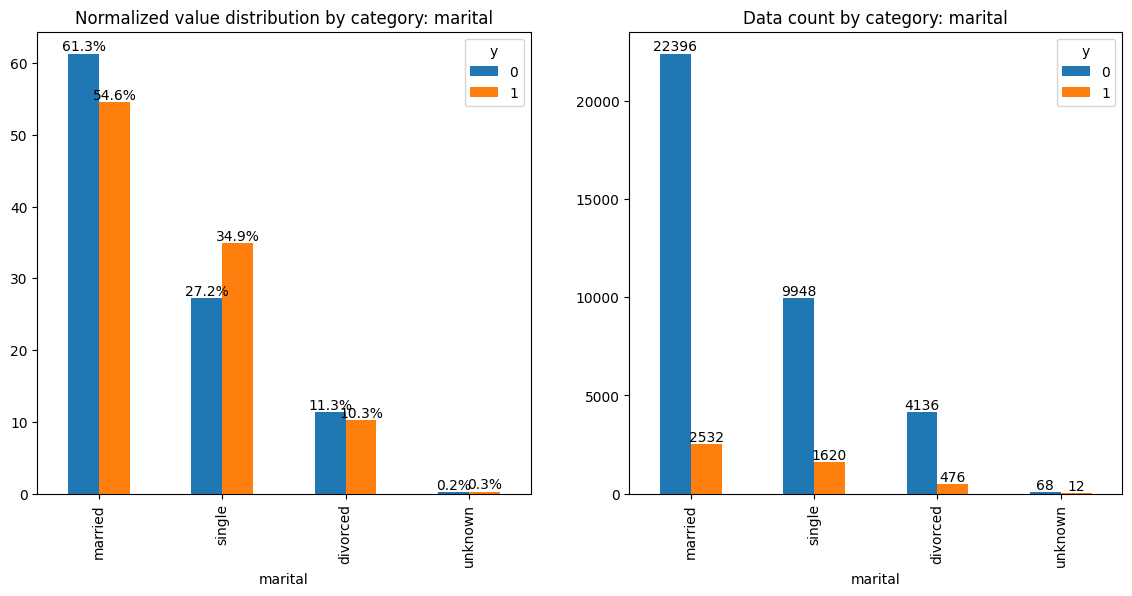

In [8]:
uni_cat_target_compare(df_bank,'marital')

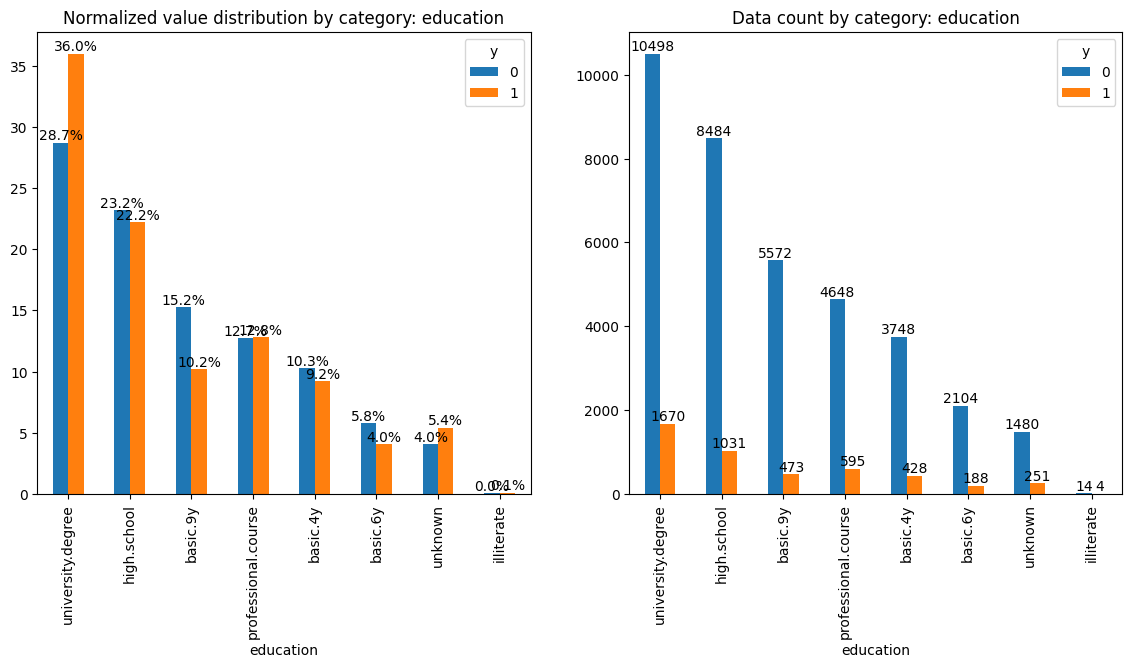

In [9]:
uni_cat_target_compare(df_bank,'education')

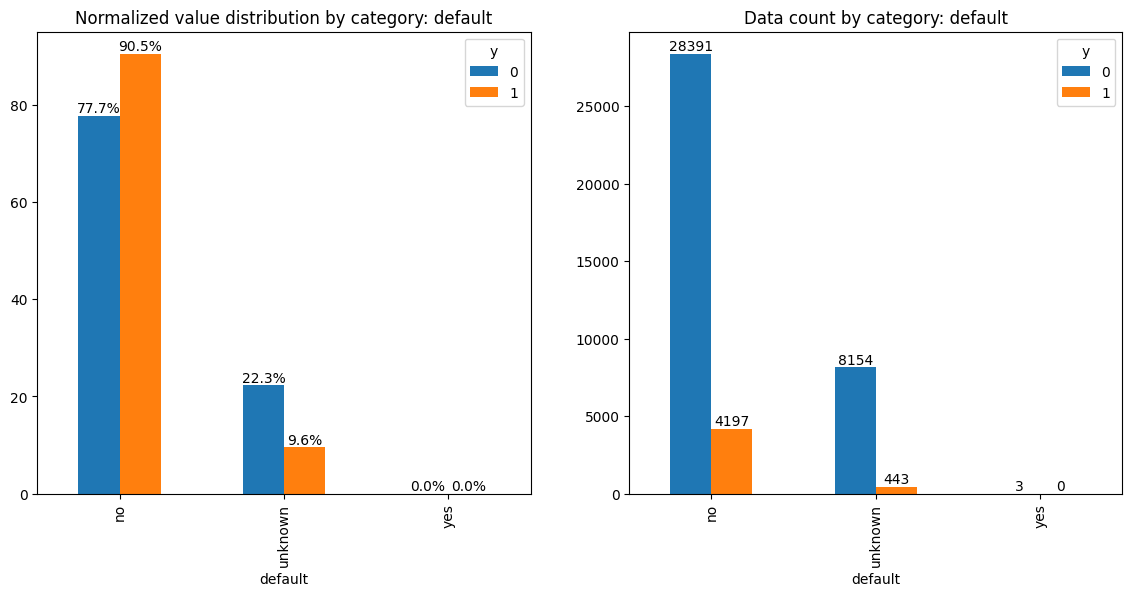

In [10]:
uni_cat_target_compare(df_bank,'default')

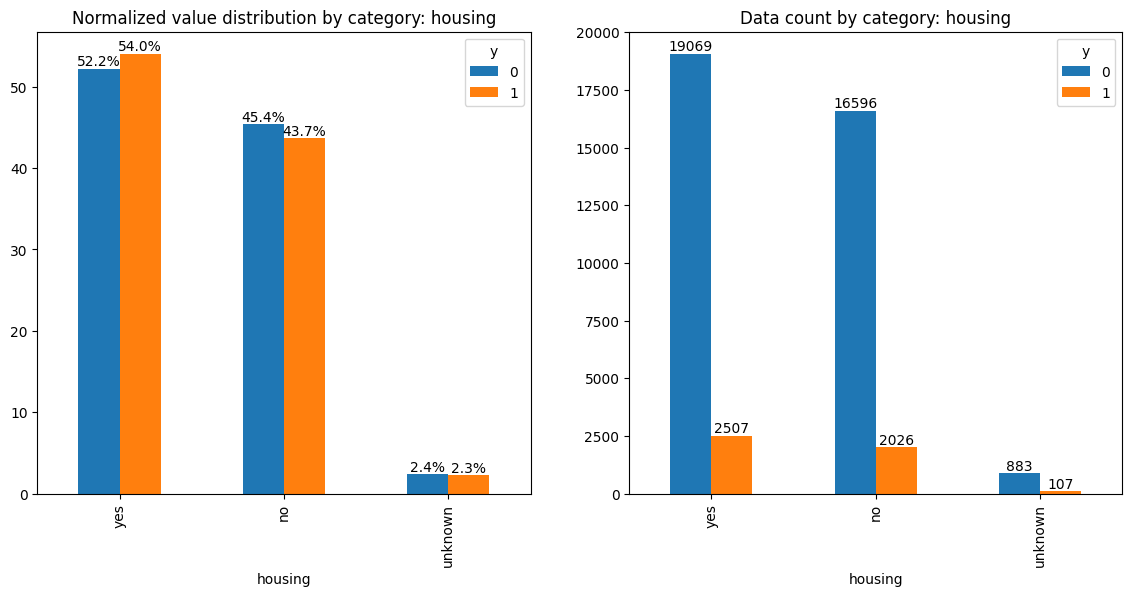

In [11]:
uni_cat_target_compare(df_bank,'housing')

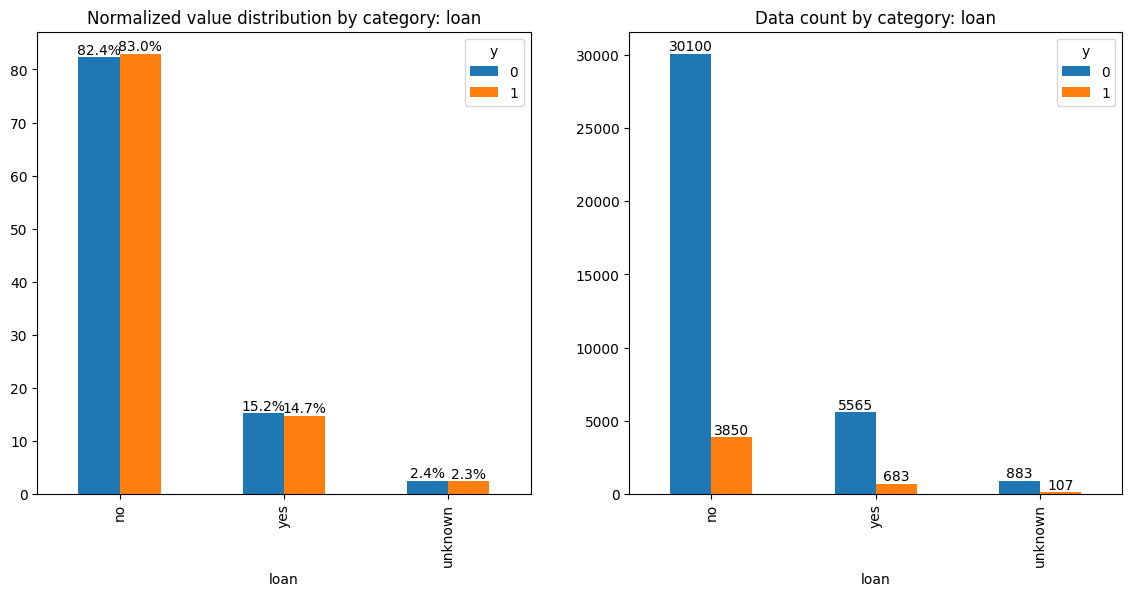

In [12]:
uni_cat_target_compare(df_bank,'loan')

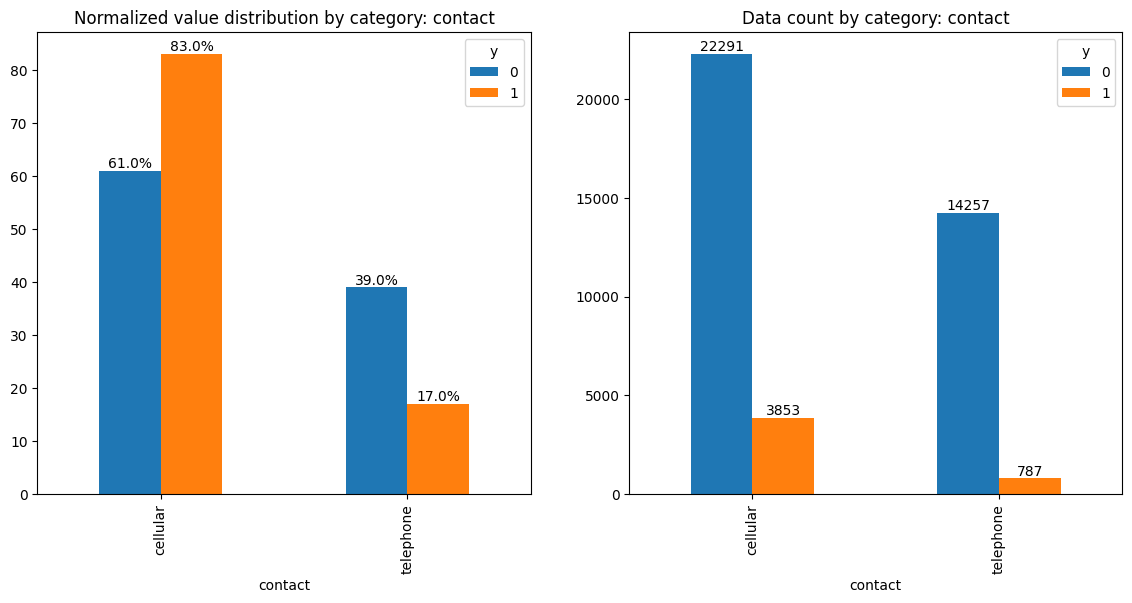

In [13]:
uni_cat_target_compare(df_bank,'contact')

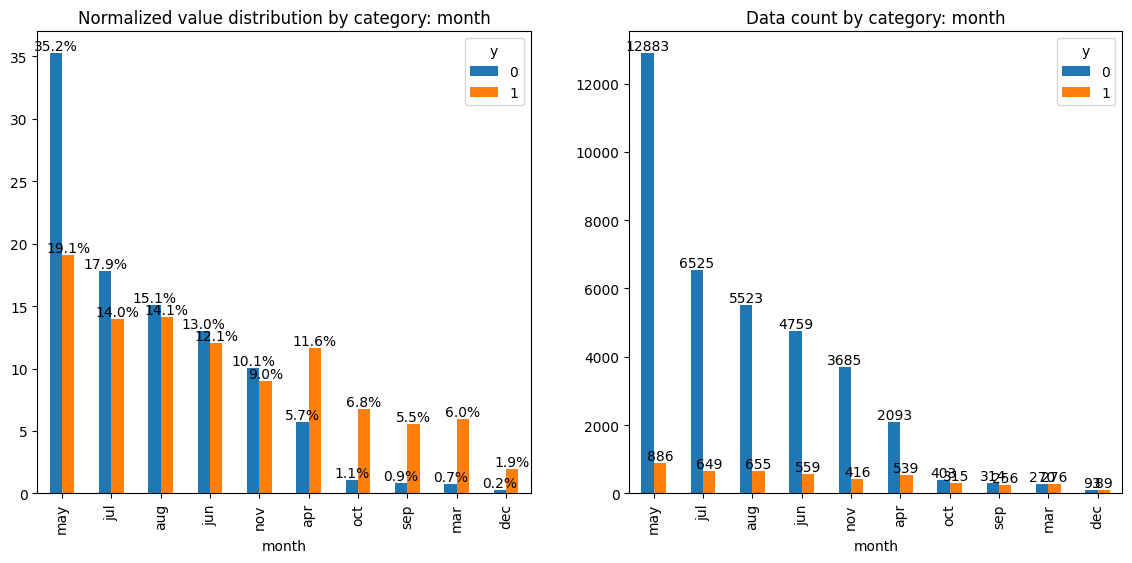

In [14]:
uni_cat_target_compare(df_bank,'month')

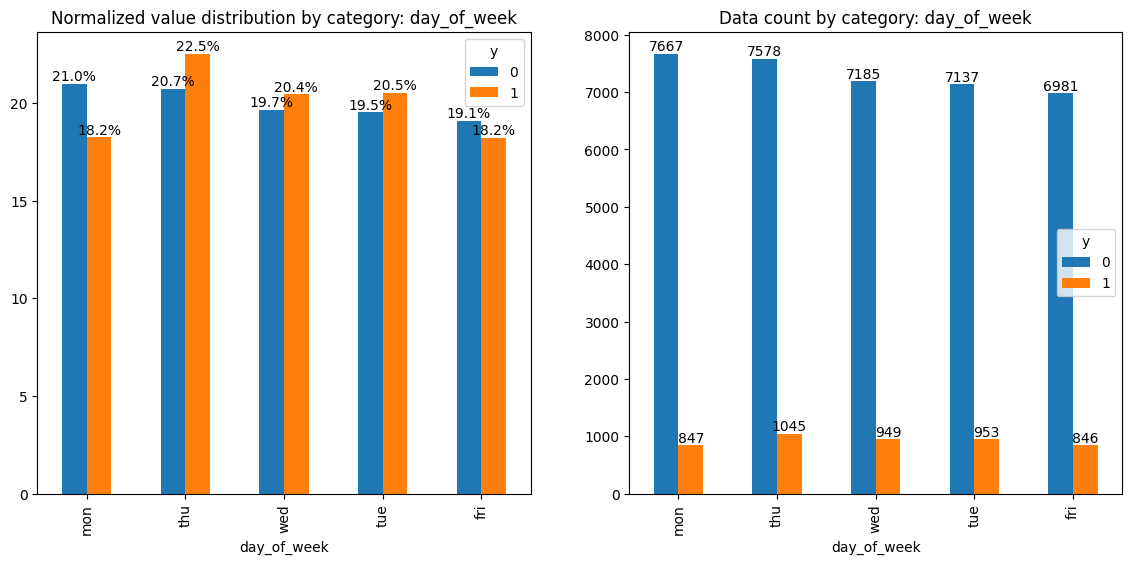

In [15]:
uni_cat_target_compare(df_bank,'day_of_week')

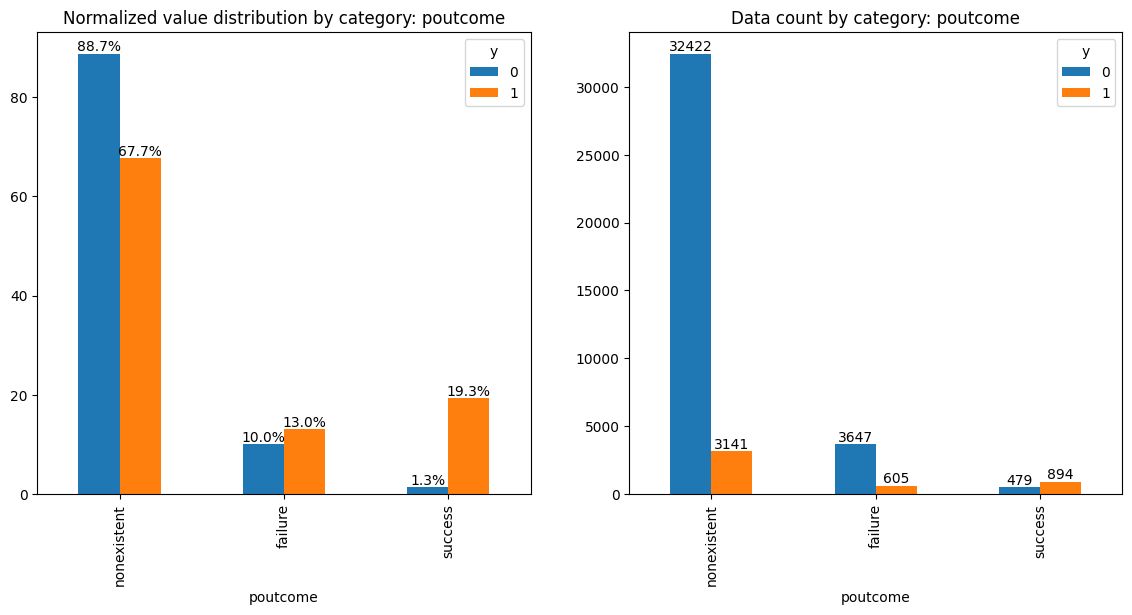

In [16]:
uni_cat_target_compare(df_bank,'poutcome')

### Conclusions
1. All categorical columns contain no missing values
2. Except for the columns job, education, month, the others contain few unique values - this will help when choosing the categorical encoding method
3. The month column can be encoded with the corresponding ordinal month number, similar to day_of_week
4. The education column can be encoded from 0 to 6 by increasing education level - from unknown to university
5. The columns housing, loan, day_of_week have no impact on the target
6. default contains very few yes values, only 3
, so they can either be removed or merged into unknown
7. The following columns are significant: poutcome, job, education, default, contact, month


## Numerical features

### Let's look at the data distribution - mean, median, and percentiles

In [17]:
numeric_df = df_bank.select_dtypes(include=['number'])
numeric_df = numeric_df.drop(columns=['y', 'duration'])
stats = numeric_df.describe().T


stats['median'] = numeric_df.median()
stats['missing_values'] = numeric_df.isnull().sum()

result = stats[['missing_values', 'mean', 'median', '25%', '50%', '75%']]
result_rounded = result.round(2)
print(result_rounded)


                missing_values     mean   median      25%      50%      75%
age                          0    40.02    38.00    32.00    38.00    47.00
campaign                     0     2.57     2.00     1.00     2.00     3.00
pdays                        0   962.48   999.00   999.00   999.00   999.00
previous                     0     0.17     0.00     0.00     0.00     0.00
emp.var.rate                 0     0.08     1.10    -1.80     1.10     1.40
cons.price.idx               0    93.58    93.75    93.08    93.75    93.99
cons.conf.idx                0   -40.50   -41.80   -42.70   -41.80   -36.40
euribor3m                    0     3.62     4.86     1.34     4.86     4.96
nr.employed                  0  5167.04  5191.00  5099.10  5191.00  5228.10


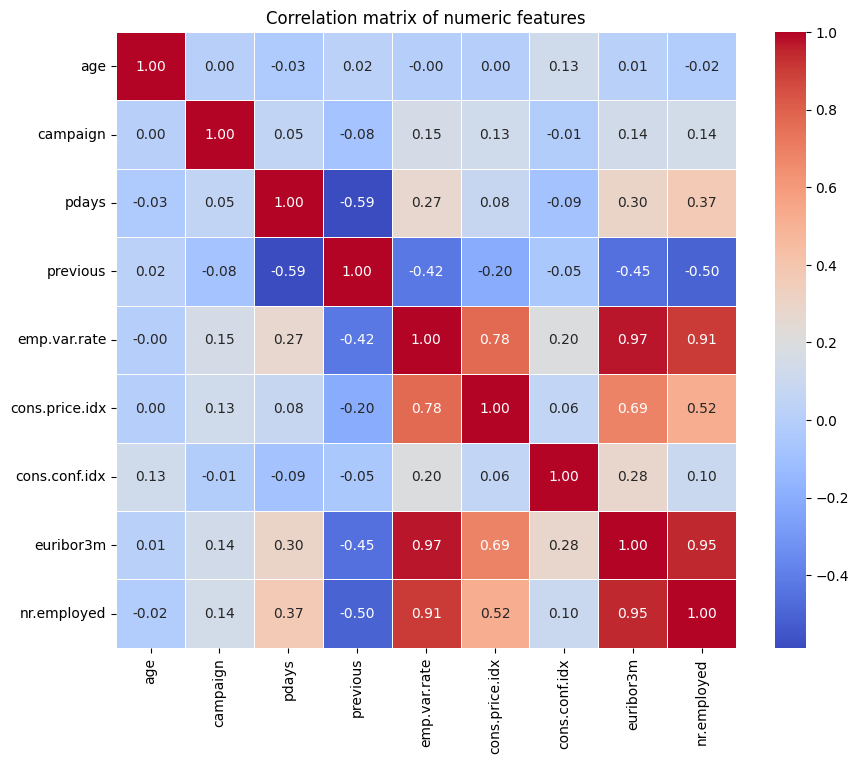

In [18]:
# calculate the correlation matrix
corr_matrix = numeric_df.corr()

# build the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation matrix of numeric features')
plt.show()

In [19]:
# pdays (number of days since last contact) - 999 is a placeholder; better to turn the column into 0 - not contacted, 1 - contacted
df_bank['pdays'] = np.where(df_bank['pdays'] == 999, 0, 1)

Text(0.5, 0, 'Number of contacts')

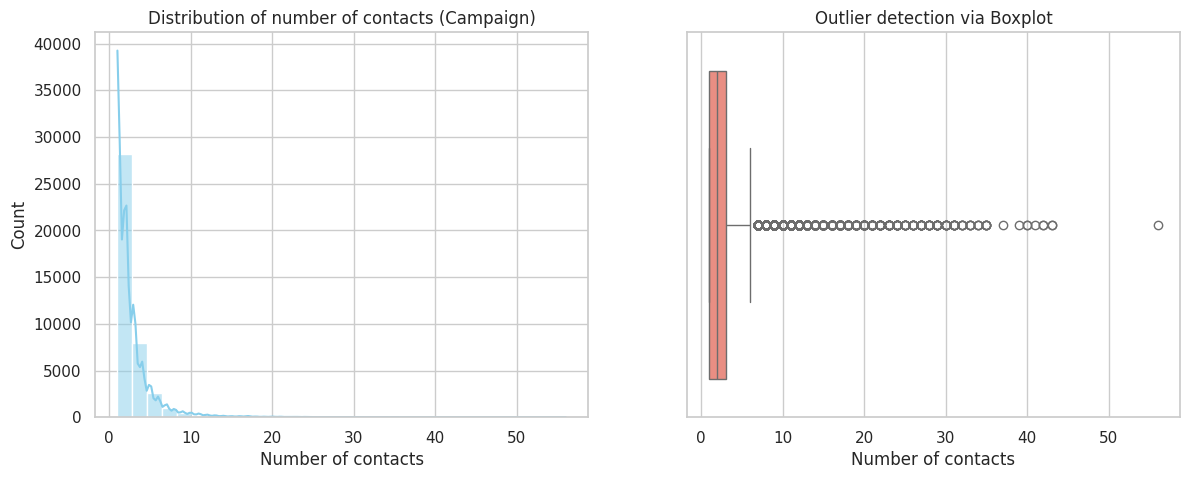

In [20]:
# question - campaign - the mean is higher than the median, there may be outliers, need to check the max value.
sns.set_theme(style="whitegrid")

# Create a figure with two plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram
sns.histplot(df_bank['campaign'], bins=30, kde=True, ax=ax1, color='skyblue')
ax1.set_title('Distribution of number of contacts (Campaign)')
ax1.set_xlabel('Number of contacts')

# 2. Boxplot
sns.boxplot(x=df_bank['campaign'], ax=ax2, color='salmon')
ax2.set_title('Outlier detection via Boxplot')
ax2.set_xlabel('Number of contacts')

In [21]:
# indeed there are outliers, clearly visible on the plots above. Below they are replaced with the median
Q1 = df_bank['campaign'].quantile(0.25)
Q3 = df_bank['campaign'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Replace outliers with the median
median_val = df_bank['campaign'].median()
df_bank.loc[df_bank['campaign'] > upper_bound, 'campaign'] = median_val

### Conclusions on numerical columns
1. for pdays - replaced 999 with 0, and other values with 1. Represents whether there was communication or not
2. outliers present in campaign were replaced with the median
3. euribor3m has a wide spread in the data - but for now left unchanged
4. nr.employed - has the largest value among all numeric features - will need to be normalized later
5. euribor3m, emp.var.rate, nr.employed - are very strongly correlated - for regression it would be worth keeping only one feature, but regression is only a baseline, and LGBM and RF are not sensitive to multicollinearity, so for now I keep all three variables.

# choosing data processing methods, preparation, and selecting the evaluation metric

### Model quality evaluation
As the evaluation metric I will use F1, since the target has a class imbalance - those who opened a deposit are far fewer than those who did not.
The focus is on prediction quality for the positive class.


### Data processing
Since two of the models require detailed data processing, for regression and KNN we will make the following transformations
1. we will make changes to the categorical columns based on the EDA conclusions:
  *   the month column can be encoded with the corresponding ordinal month number, similar to day_of_week
* the education column can be encoded from 0 to 6 by increasing education level - from unknown to university


*    default contains very few yes values, only 3, so they can either be removed or merged into unknown
2. normalize the numeric features
3. transform the categorical features
4. train the models and evaluate their quality
5. then move on to trees and boosting

In [22]:
df_bank = df_bank.drop(columns=[ 'duration'])
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

In [23]:
# the month column can be encoded with the corresponding ordinal month number, similar to day_of_week

month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

df_bank['month'] = df_bank['month'].map(month_map)


dow_map = {
    'mon': 1,
    'tue': 2,
    'wed': 3,
    'thu': 4,
    'fri': 5
}

df_bank['day_of_week'] = df_bank['day_of_week'].map(dow_map)


In [24]:
# the education column can be encoded from 0 to 6 by increasing education level - from unknown to university
education_map = {
    'illiterate': 0,
    'basic.4y': 1,
    'basic.6y': 2,
    'basic.9y': 3,
    'high.school': 4,
    'professional.course': 5,
    'university.degree': 6,
    'unknown': 3              # Median value
}

df_bank['education'] = df_bank['education'].map(education_map)

In [25]:
# default contains very few yes values, only 3, so they can either be removed or merged into unknown
df_bank['default'] = df_bank['default'].replace('yes', 'unknown')

In [26]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  int64  
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  int64  
 9   day_of_week     41188 non-null  int64  
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

In [27]:
# Create the training and test sets
train_df_, test_df = train_test_split(df_bank, test_size=0.2, random_state=42,stratify=df_bank['y'])

input_cols=list(df_bank.columns)[0:-1]
target_col='y'
test_inputs=test_df[input_cols].copy()
test_targets=test_df[target_col].copy()

In [28]:
# Additional split: train -> train + val
train_df, val_df = train_test_split(
    train_df_, test_size=0.2, random_state=42, stratify=train_df_['y']
)
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [29]:
# Identify numeric and categorical columns
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()
# Create transformers for numeric and categorical columns
numeric_transformer = Pipeline(steps=[

    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Combine transformers for different column types into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


# Function to predict and compute metrics
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    y_pred_proba = model_pipeline.predict_proba(inputs)[:, 1]
    f1 = f1_score(targets, preds)
    print("F1 score: {:.2%}".format(f1))
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)


    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds


## Logistic Regression

In [30]:
# Create a pipeline that first runs preprocessing, then trains the model
model_pipeline_LR = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', class_weight='balanced'))

])


# Train the pipeline
model_pipeline_LR.fit(train_inputs, train_targets)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education', 'month',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'poutcome'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced',
                                    solver='liblinear'))])

F1 score: 40.59%


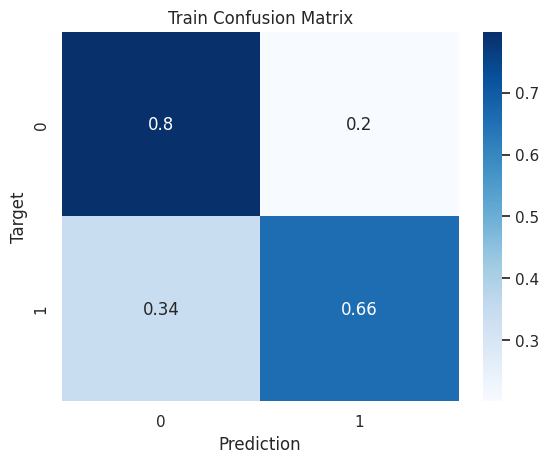

F1 score: 40.46%


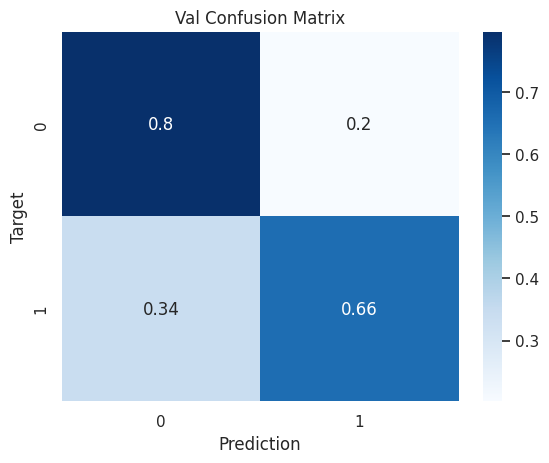

In [31]:
# Evaluate the model on train and test data
train_preds = predict_and_plot(model_pipeline_LR,train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_LR,val_inputs, val_targets, 'Val')


# KNN

In [32]:
# 1. Create the base pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

# 2. Define the parameter grid
params_knn = {
    'classifier__n_neighbors': np.arange(1, 25),
    'classifier__weights': ['uniform', 'distance']
}

# 3. Set up GridSearchCV
knn_gs = GridSearchCV(
    full_pipeline,
    params_knn,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# 4. Train
knn_gs.fit(train_inputs, train_targets)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'education',
                                                                          'month',
                                                                          'day_of_week',
                                                                          'campaign',
                                                                          'pdays',
                                                                          'previous',
                                                                          'emp.var.rate',
                                                                          'cons.price.idx',
                                                                          'cons.conf.idx',
                                                                          'euribor3m',
                                                                          'nr.employed']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['job',
                                                                          'marital',
                                                                          'default',
                                                                          'housing',
                                                                          'loan',
                                                                          'contact',
                                                                          'poutcome'])])),
                                       ('classifier', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24]),
                         'classifier__weights': ['uniform', 'distance']},
             scoring='f1')

F1 score: 47.64%


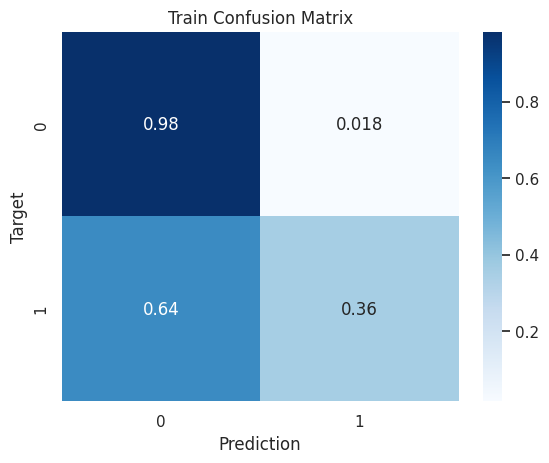

F1 score: 37.62%


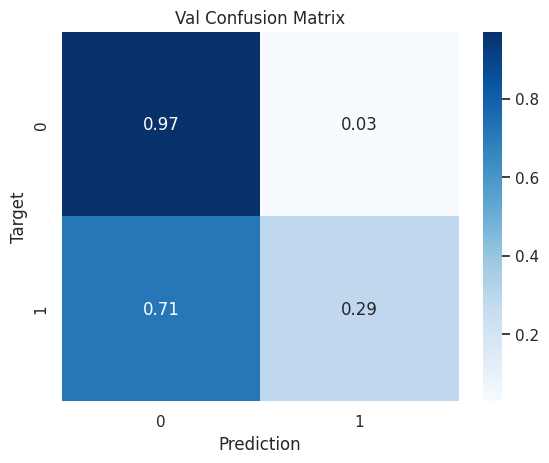

In [33]:
# Evaluate the model
train_preds = predict_and_plot(knn_gs,train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(knn_gs,val_inputs, val_targets, 'Val')

#### KNN - the model performs worse than LR. Since this method is quite slow computationally, I will try other models, namely trees and boosting.

##RandomForest

In [34]:
model_pipeline_RF = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
              n_estimators=200,
              max_depth=8,
               max_leaf_nodes=40,
              max_features='sqrt',
              class_weight='balanced',
              random_state=42,
             n_jobs=-1
    ))
])



# Training
model_pipeline_RF.fit(train_inputs, train_targets)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education', 'month',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'poutcome'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        max_leaf_nodes=40, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

F1 score: 47.27%


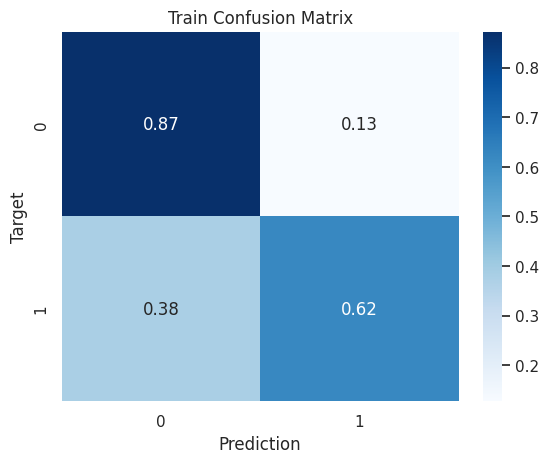

F1 score: 47.13%


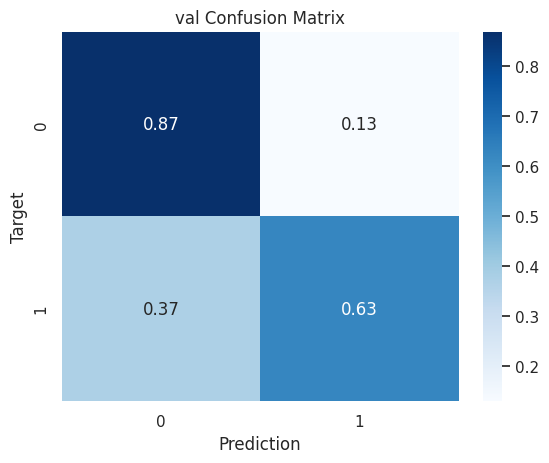

In [35]:
# Evaluate the model
train_preds = predict_and_plot(model_pipeline_RF,train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_RF,val_inputs, val_targets, 'val')

So far the result is better than KNN. Let's tune the hyperparameters to select the best parameters for the model.

In [36]:
# define the hyperparameter tuning function for RF
def rf_hyperparameter_experiment(X_train, y_train, X_val, y_val):


    results = {'iter': [], 'val_auc': [], 'val_f1': []}

    # Parameters to iterate over
    depths = [5, 10, 15, 20]
    min_samples = [10, 30, 50, 100]

    counter = 0
    best_f1 = 0
    best_params = {}

    print(f"{'Iter':<5} | {'Depth':<5} | {'MinLeaf':<7} | {'Val AUC':<10} | {'Val F1':<10}")
    print("-" * 55)

    for depth in depths:
        for min_leaf in min_samples:
            counter += 1

            # Training

            model = RandomForestClassifier(
                n_estimators=100,
                max_depth=depth,
                min_samples_leaf=min_leaf,
                 max_features='sqrt',
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
            model.fit(X_train, y_train)

            # Metrics
            val_probs = model.predict_proba(X_val)[:, 1]
            val_preds = model.predict(X_val)

            v_auc = roc_auc_score(y_val, val_probs)
            v_f1 = f1_score(y_val, val_preds)

            results['iter'].append(counter)
            results['val_auc'].append(v_auc)
            results['val_f1'].append(v_f1)

            if v_f1 > best_f1:
                best_f1 = v_f1
                best_params = {'depth': depth, 'min_leaf': min_leaf, 'f1': v_f1, 'auc': v_auc}

            print(f"{counter:<5} | {depth:<5} | {min_leaf:<7} | {v_auc:.4f}    | {v_f1:.4f}")

    # Comparison plot
    plt.figure(figsize=(10, 5))
    plt.plot(results['iter'], results['val_auc'], label='Val AUC', marker='o')
    plt.plot(results['iter'], results['val_f1'], label='Val F1', marker='s', color='green')
    plt.title('Random Forest Tuning')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
    return best_params

Iter  | Depth | MinLeaf | Val AUC    | Val F1    
-------------------------------------------------------
1     | 5     | 10      | 0.7963    | 0.4453
2     | 5     | 30      | 0.7969    | 0.4502
3     | 5     | 50      | 0.7964    | 0.4417
4     | 5     | 100     | 0.7955    | 0.4364
5     | 10    | 10      | 0.8054    | 0.4859
6     | 10    | 30      | 0.8053    | 0.4769
7     | 10    | 50      | 0.8035    | 0.4680
8     | 10    | 100     | 0.8025    | 0.4552
9     | 15    | 10      | 0.8047    | 0.4949
10    | 15    | 30      | 0.8040    | 0.4807
11    | 15    | 50      | 0.8038    | 0.4737
12    | 15    | 100     | 0.8020    | 0.4583
13    | 20    | 10      | 0.8062    | 0.5030
14    | 20    | 30      | 0.8043    | 0.4769
15    | 20    | 50      | 0.8051    | 0.4715
16    | 20    | 100     | 0.8018    | 0.4576


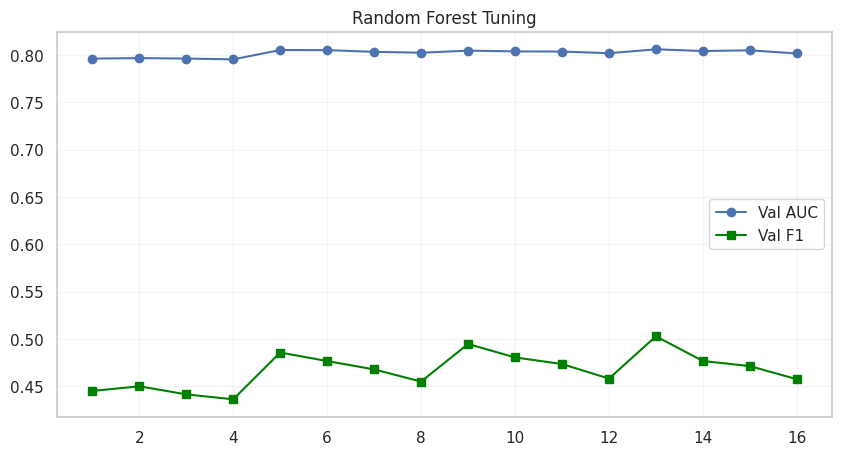

{'depth': 20,
 'min_leaf': 10,
 'f1': 0.5030203185063152,
 'auc': np.float64(0.8061558816154808)}

In [37]:
X_train_RF = preprocessor.fit_transform(train_inputs)
X_val_RF   = preprocessor.transform(val_inputs)

rf_hyperparameter_experiment(X_train_RF, train_targets, X_val_RF, val_targets)



In [38]:
model_pipeline_RF_best = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
              n_estimators=100,
              max_depth=20,
               min_samples_leaf=10,
              max_features='sqrt',
              class_weight='balanced',
              random_state=42,
             n_jobs=-1
    ))
])



# Training
model_pipeline_RF_best.fit(train_inputs, train_targets)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education', 'month',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'poutcome'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=20,
                                        min_samples_leaf=10, n_jobs=-1,
                                        random_state=42))])

F1 score: 53.34%


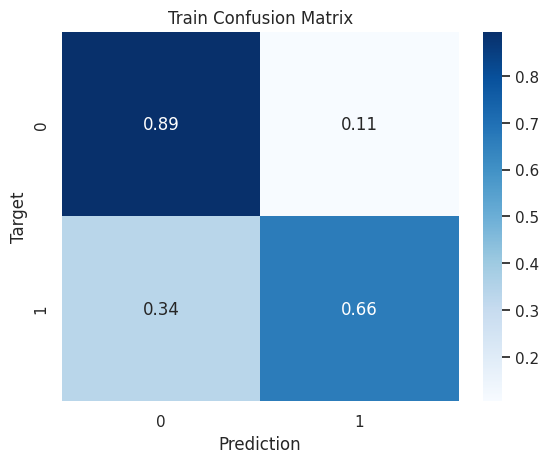

F1 score: 50.30%


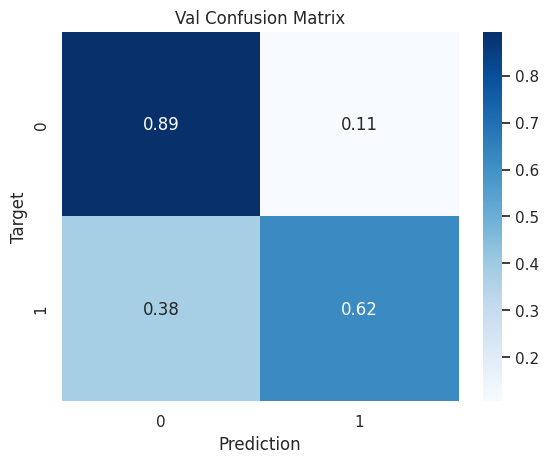

In [39]:
train_preds = predict_and_plot(model_pipeline_RF_best,train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_RF_best,val_inputs, val_targets, 'Val')

### At this stage, the best parameters are
depth=20, min_leaf=10, with f1=0.5030, which is currently the best result.

### Let's look at the top 10 important features, and also remove the unimportant ones

                      feature  importance
11           num__nr.employed    0.227542
10             num__euribor3m    0.201457
7           num__emp.var.rate    0.138344
9          num__cons.conf.idx    0.077455
2                  num__month    0.051192
8         num__cons.price.idx    0.050263
5                  num__pdays    0.047463
40      cat__poutcome_success    0.033803
6               num__previous    0.030007
39  cat__poutcome_nonexistent    0.019476


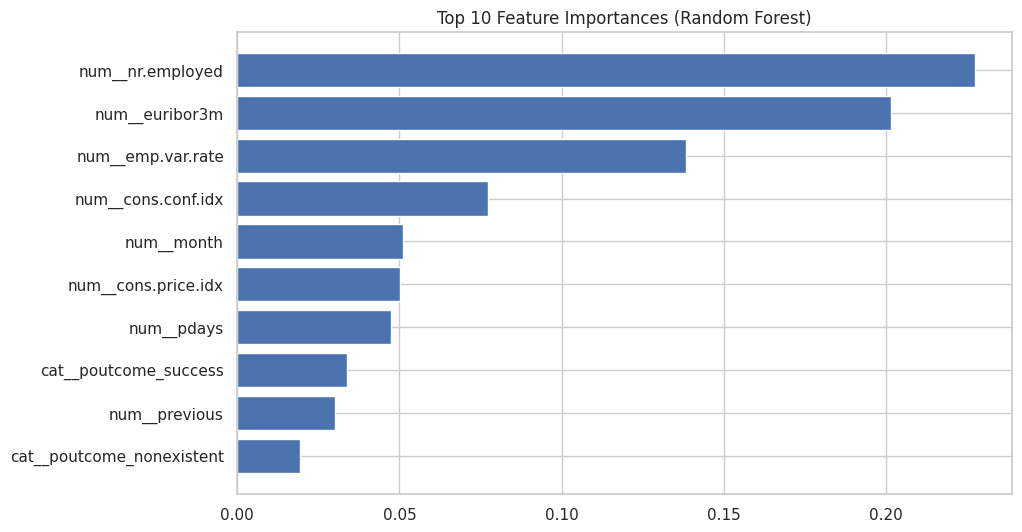

In [40]:
feature_names = model_pipeline_RF.named_steps['preprocessor'].get_feature_names_out()

# Extract the feature importances from the forest model
importances = model_pipeline_RF.named_steps['classifier'].feature_importances_

# Create a convenient DataFrame
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Print the TOP-10 features
print(feature_importance_df.head(10))

# Visualization
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'][:10], feature_importance_df['importance'][:10])
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances (Random Forest)')
plt.show()

In [41]:
feature_names = model_pipeline_RF.named_steps['preprocessor'].get_feature_names_out()
importances = model_pipeline_RF.named_steps['classifier'].feature_importances_

# Create a list of "useful" features
threshold = 0.001
important_features = feature_names[importances >= threshold]
unimportant_features = feature_names[importances < threshold]

print(f"Removing {len(unimportant_features)} features.")
print(f"Keeping {len(important_features)} features.")

Removing 14 features.
Keeping 27 features.


let's remove the unimportant features and retrain the model


Iter  | Depth | MinLeaf | Val AUC    | Val F1    
-------------------------------------------------------
1     | 5     | 10      | 0.7974    | 0.4572
2     | 5     | 30      | 0.7975    | 0.4594
3     | 5     | 50      | 0.7985    | 0.4555
4     | 5     | 100     | 0.7958    | 0.4551
5     | 10    | 10      | 0.8076    | 0.4866
6     | 10    | 30      | 0.8070    | 0.4760
7     | 10    | 50      | 0.8074    | 0.4746
8     | 10    | 100     | 0.8037    | 0.4620
9     | 15    | 10      | 0.8061    | 0.4970
10    | 15    | 30      | 0.8097    | 0.4851
11    | 15    | 50      | 0.8064    | 0.4756
12    | 15    | 100     | 0.8054    | 0.4606
13    | 20    | 10      | 0.8067    | 0.4981
14    | 20    | 30      | 0.8072    | 0.4843
15    | 20    | 50      | 0.8066    | 0.4735
16    | 20    | 100     | 0.8056    | 0.4615


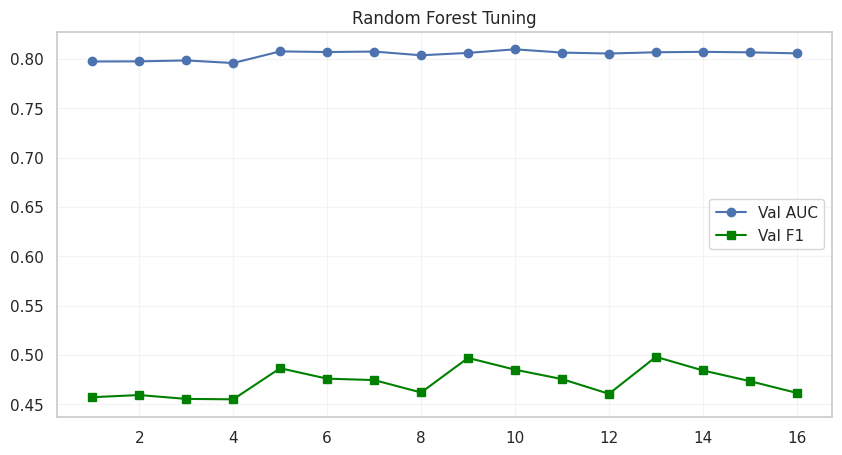

{'depth': 20,
 'min_leaf': 10,
 'f1': 0.49810503519220356,
 'auc': np.float64(0.8067147383306108)}

In [42]:
set_config(transform_output="pandas")

X_train_RF = preprocessor.fit_transform(train_inputs)
X_val_RF   = preprocessor.transform(val_inputs)

train_inputs_RF = X_train_RF.drop(columns=unimportant_features)
val_inputs_RF   = X_val_RF.drop(columns=unimportant_features)

rf_hyperparameter_experiment(train_inputs_RF, train_targets, val_inputs_RF, val_targets)


after removing the unimportant features, model quality decreased, so I will move on to boosting, then compare all results on the validation data, and test the final model on the test set

##LGBMClassifier

In [43]:
# 1. Create the final pipeline
model_pipeline_LGBM = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectFromModel(LGBMClassifier(n_estimators=100, random_state=42), threshold='median')),
       ('model', LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.02,
        max_depth=6,
        num_leaves=55,
        #is_unbalance=True,
        scale_pos_weight=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])

# 2. Train the whole pipeline at once
model_pipeline_LGBM.fit(train_inputs, train_targets)

[LightGBM] [Info] Number of positive: 2970, number of negative: 23390
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006270 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 381
[LightGBM] [Info] Number of data points in the train set: 26360, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112671 -> initscore=-2.063747
[LightGBM] [Info] Start training from score -2.063747


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education', 'month',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'poutcome'])])),
                ('selector',
                 SelectFromModel(estimator=LGBMClassifier(random_state=42),
                                 threshold='median')),
                ('model',
                 LGBMClassifier(colsample_bytree=0.8, learning_rate=0.02,
                                max_depth=6, n_estimators=1000, n_jobs=-1,
                                num_leaves=55, random_state=42,
                                scale_pos_weight=6, subsample=0.8,
                                verbosity=-1))])

F1 score: 56.39%


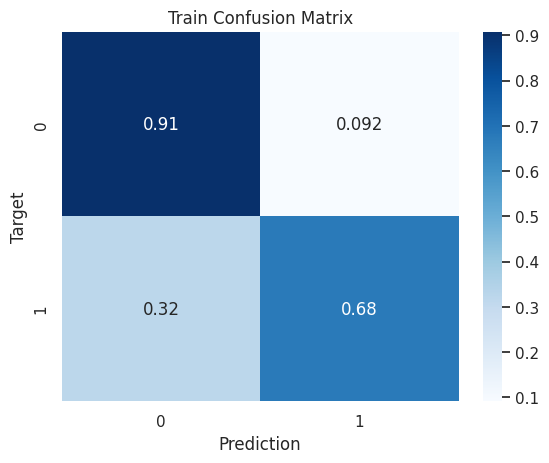

F1 score: 50.42%


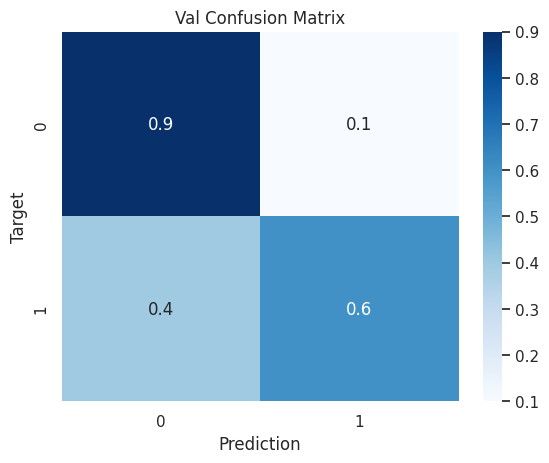

In [44]:
train_preds = predict_and_plot(model_pipeline_LGBM,train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_LGBM,val_inputs, val_targets, 'Val')

In [45]:
# let's look at the metrics as thresholds change
probs = model_pipeline_LGBM.predict_proba(val_inputs)[:, 1]

thresholds = [0.50, 0.55, 0.62, 0.65, 0.68, 0.70, 0.8]

for threshold in thresholds:
    preds = (probs > threshold).astype(int)

    precision = precision_score(val_targets, preds)
    recall = recall_score(val_targets, preds)
    f1 = f1_score(val_targets, preds)
    print(f"Threshold: {threshold:.2f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")



Threshold: 0.50 | Precision: 0.4336 | Recall: 0.6024 | F1: 0.5042
Threshold: 0.55 | Precision: 0.4499 | Recall: 0.5755 | F1: 0.5050
Threshold: 0.62 | Precision: 0.4831 | Recall: 0.5377 | F1: 0.5089
Threshold: 0.65 | Precision: 0.4942 | Recall: 0.5189 | F1: 0.5062
Threshold: 0.68 | Precision: 0.5142 | Recall: 0.4892 | F1: 0.5014
Threshold: 0.70 | Precision: 0.5228 | Recall: 0.4636 | F1: 0.4914
Threshold: 0.80 | Precision: 0.5874 | Recall: 0.2898 | F1: 0.3881


###RandomizedSearchCV

In [46]:
param_dist = {
    'model__n_estimators': [500, 1000, 1500],
    'model__learning_rate': [0.01, 0.02, 0.05],
    'model__max_depth': [4, 6, 8, 10],
    'model__num_leaves': [20, 31, 63, 127],
    'model__scale_pos_weight': [5, 8, 10, 12],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.6, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    model_pipeline_LGBM,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42
)

random_search.fit(train_inputs, train_targets)
best_model_RS = random_search.best_estimator_
print("Best parameters (RandomSearch):", random_search.best_params_)


Best parameters (RandomSearch): {'model__subsample': 0.8, 'model__scale_pos_weight': 5, 'model__num_leaves': 127, 'model__n_estimators': 1000, 'model__max_depth': 4, 'model__learning_rate': 0.02, 'model__colsample_bytree': 1.0}


In [47]:
# let's look at the metrics as thresholds change
probs = best_model_RS.predict_proba(val_inputs)[:, 1]

thresholds = [0.50, 0.55, 0.62, 0.65, 0.68, 0.70, 0.8]

for threshold in thresholds:
    preds = (probs > threshold).astype(int)

    precision = precision_score(val_targets, preds)
    recall = recall_score(val_targets, preds)
    f1 = f1_score(val_targets, preds)
    print(f"Threshold: {threshold:.2f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")



Threshold: 0.50 | Precision: 0.4389 | Recall: 0.5997 | F1: 0.5068
Threshold: 0.55 | Precision: 0.4539 | Recall: 0.5836 | F1: 0.5106
Threshold: 0.62 | Precision: 0.4858 | Recall: 0.5526 | F1: 0.5170
Threshold: 0.65 | Precision: 0.4968 | Recall: 0.5243 | F1: 0.5102
Threshold: 0.68 | Precision: 0.5229 | Recall: 0.4771 | F1: 0.4989
Threshold: 0.70 | Precision: 0.5462 | Recall: 0.4461 | F1: 0.4911
Threshold: 0.80 | Precision: 0.6195 | Recall: 0.2830 | F1: 0.3885


###hyperopt

In [48]:
def objective(params):
    model_pipeline_LGBM.set_params(
        model__n_estimators=int(params['n_estimators']),
        model__max_depth=int(params['max_depth']),
        model__num_leaves=int(params['num_leaves']),
        model__learning_rate=params['learning_rate'],
        model__scale_pos_weight=params['scale_pos_weight']
    )

    score = cross_val_score(model_pipeline_LGBM, train_inputs, train_targets, cv=3, scoring='f1').mean()
    return {'loss': -score, 'status': STATUS_OK}

space = {
    'n_estimators': hp.quniform('n_estimators', 500, 2000, 100),
    'max_depth': hp.quniform('max_depth', 4, 12, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.005), np.log(0.1)),
    'scale_pos_weight': hp.quniform('scale_pos_weight', 5, 15, 1)
}

best = fmin(
    fn=objective, space=space, algo=tpe.suggest, max_evals=30,
    trials=Trials(),
    rstate=np.random.default_rng(42)
)
print("Best parameters (Hyperopt):", best)


100%|██████████| 30/30 [07:49<00:00, 15.65s/trial, best loss: -0.48986323071189314]
Best parameters (Hyperopt): {'learning_rate': np.float64(0.005354733491750849), 'max_depth': np.float64(4.0), 'n_estimators': np.float64(1900.0), 'num_leaves': np.float64(61.0), 'scale_pos_weight': np.float64(5.0)}


In [49]:
final_model_hyperopt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectFromModel(LGBMClassifier(n_estimators=100, random_state=42), threshold='1.25*mean')),
    ('model', LGBMClassifier(
        n_estimators=int(best['n_estimators']),
        learning_rate=best['learning_rate'],
        max_depth=int(best['max_depth']),
        num_leaves=int(best['num_leaves']),
        scale_pos_weight=best['scale_pos_weight'],
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1
    ))
])


final_model_hyperopt.fit(train_inputs, train_targets)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education', 'month',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=F...
                                                   'housing', 'loan', 'contact',
                                                   'poutcome'])])),
                ('selector',
                 SelectFromModel(estimator=LGBMClassifier(random_state=42),
                                 threshold='1.25*mean')),
                ('model',
                 LGBMClassifier(colsample_bytree=0.8,
                                learning_rate=np.float64(0.005354733491750849),
                                max_depth=4, n_estimators=1900, num_leaves=61,
                                random_state=42,
                                scale_pos_weight=np.float64(5.0), subsample=0.8,
                                verbosity=-1))])

In [50]:
# let's look at the metrics as thresholds change
probs = final_model_hyperopt.predict_proba(val_inputs)[:, 1]

thresholds = [0.50, 0.55, 0.62, 0.65, 0.68, 0.70]

for threshold in thresholds:
    preds = (probs > threshold).astype(int)

    precision = precision_score(val_targets, preds)
    recall = recall_score(val_targets, preds)
    f1 = f1_score(val_targets, preds)
    print(f"Threshold: {threshold:.2f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")



Threshold: 0.50 | Precision: 0.4196 | Recall: 0.6011 | F1: 0.4942
Threshold: 0.55 | Precision: 0.4324 | Recall: 0.5863 | F1: 0.4977
Threshold: 0.62 | Precision: 0.4504 | Recall: 0.5633 | F1: 0.5006
Threshold: 0.65 | Precision: 0.4580 | Recall: 0.5512 | F1: 0.5003
Threshold: 0.68 | Precision: 0.4729 | Recall: 0.5283 | F1: 0.4990
Threshold: 0.70 | Precision: 0.4814 | Recall: 0.4892 | F1: 0.4853


# Model results table

In [51]:
# 1. Dictionary of models
models_to_compare = {
    "Baseline LGBM": model_pipeline_LGBM,
    "Randomized Search LGBM": best_model_RS,
    "Hyperopt LGBM": final_model_hyperopt,
    "RandomForest" :model_pipeline_RF_best,
    "LRegression": model_pipeline_LR,
    "KNN":knn_gs
}

# 2. Function to collect metrics
def get_metrics(model, inputs, targets, threshold=0.55):
    probs = model.predict_proba(inputs)[:, 1]
    preds = (probs > threshold).astype(int)
    return {
        'F1': f1_score(targets, preds),
        'Precision': precision_score(targets, preds),
        'Recall': recall_score(targets, preds)
    }

# 3. Loop to build the table
results = []
threshold = 0.55

for name, model in models_to_compare.items():
    # Metrics on train
    train_m = get_metrics(model, train_inputs, train_targets, threshold)
    # Metrics on val
    val_m = get_metrics(model, val_inputs, val_targets, threshold)
    # Metrics on test
    test_m = get_metrics(model, test_inputs, test_targets, threshold)

    results.append({
        'Model Name': name,
        'Train F1': train_m['F1'],
        'Val F1': val_m['F1'],
        'Test F1': test_m['F1'],
        'Test Precision': test_m['Precision'],
        'Test Recall': test_m['Recall']
    })

# 4. Print the table
df_results = pd.DataFrame(results)
print(df_results.round(3).to_markdown(index=False))


| Model Name             |   Train F1 |   Val F1 |   Test F1 |   Test Precision |   Test Recall |
|:-----------------------|-----------:|---------:|----------:|-----------------:|--------------:|
| Baseline LGBM          |      0.569 |    0.505 |     0.52  |            0.464 |         0.593 |
| Randomized Search LGBM |      0.521 |    0.511 |     0.525 |            0.468 |         0.599 |
| Hyperopt LGBM          |      0.504 |    0.498 |     0.517 |            0.455 |         0.599 |
| RandomForest           |      0.517 |    0.509 |     0.524 |            0.454 |         0.62  |
| LRegression            |      0.432 |    0.431 |     0.451 |            0.346 |         0.645 |
| KNN                    |      0.476 |    0.376 |     0.379 |            0.584 |         0.28  |


### The best model is Randomized Search LGBM
This model has:
1.  the highest Test F1 score (0.525). This means it makes the fewest errors overall.
It's worth noting that Baseline LGBM has a significantly higher Train F1 (0.57) compared to the chosen model (0.52), which is a sign of overfitting. In contrast, Randomized Search LGBM shows minimal variation
between Train (0.52), Val (0.51), and Test (0.525) - this indicates a better generalization ability of the model.
2.  Precision (~0.47). For the bank, this means that almost every second call will be successful.


## Analysis of feature impact on predictions using the SHAP library for the Randomized Search LGBM model

In [52]:
# 1. Extract the transformed data (after preprocessing and feature selection)
preprocessor = best_model_RS.named_steps['preprocessor']
selector = best_model_RS.named_steps['selector']
lgbm_model = best_model_RS.named_steps['model']

X_test_proc = preprocessor.transform(test_inputs)
X_test_sel = selector.transform(X_test_proc)

feature_names = preprocessor.get_feature_names_out()
selected_features = feature_names[selector.get_support()]

X_shap = pd.DataFrame(X_test_sel, columns=selected_features)

# 2. Calculate SHAP values
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_shap)


if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]
else:
    shap_to_plot = shap_values

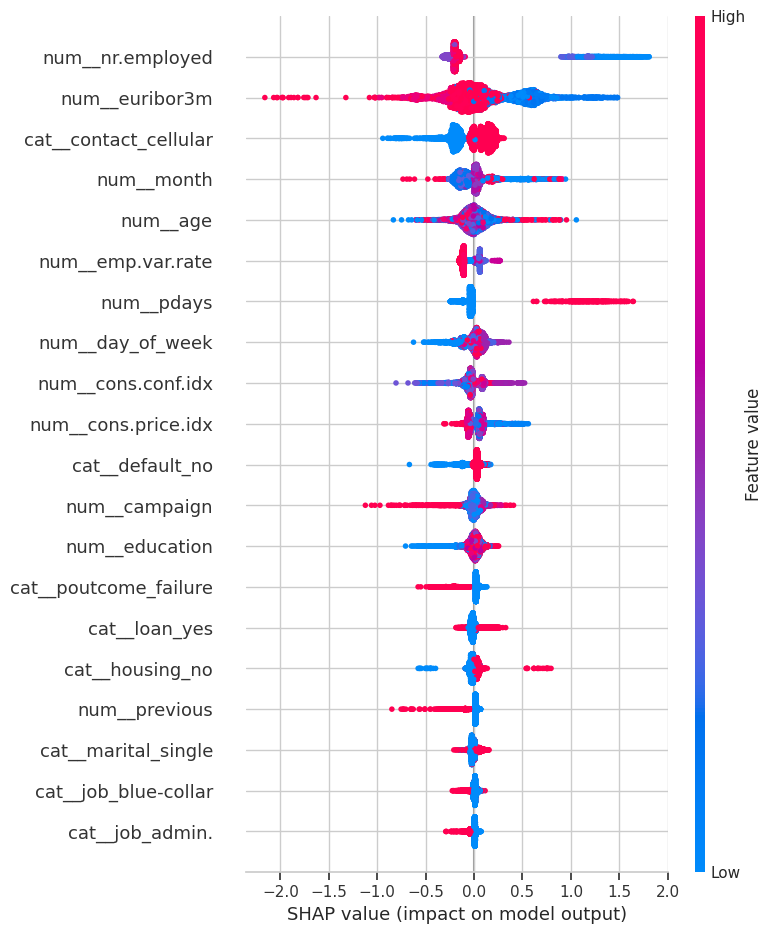

In [53]:
shap.summary_plot(shap_to_plot, X_shap)

1. the strongest features are nr.employed and euribor3m, similar to the list previously shown for RF. Low values of these indicators strongly shift the prediction to the right.
2. having a mobile phone (cellular) is a huge plus for conversion. Calls to mobile numbers are more effective than to landlines.
3. Certain months have higher conversion. It's worth checking exactly which months these are (likely end of quarter or bonus payout periods).
4. regarding pdays, the model considers new clients more promising than those who have already been called before.
5. housing_no: Clients without a mortgage open deposits more easily. This is logical - they have more free funds.

Overall, the client's personal data is far from the top factor, and economic indicators have a greater influence, indicating that the client's decision depends more on market conditions than on age and profession.

#### To improve the model, one direction is Feature Engineering - creating new, high-quality features that will further improve the model.